#### Libraries + Configuration

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.font_manager as fm
from scipy import stats
from itertools import combinations
import matplotlib
from matplotlib import rcParams

# ── Output directory
OUTPUT_DIR = Path().resolve() / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Font settings
matplotlib.rcParams["font.family"] = "DejaVu Sans"
matplotlib.rcParams["axes.unicode_minus"] = False

# ── Global style
rcParams.update({
    "figure.facecolor" : "#1B2A4A",   # Navy background
    "axes.facecolor"   : "#243558",   # Plot area
    "axes.edgecolor"   : "#4A6080",
    "axes.labelcolor"  : "#FFFFFF",   # White
    "axes.titlecolor"  : "#FFFFFF",   # White
    "xtick.color"      : "#FFFFFF",   # White
    "ytick.color"      : "#FFFFFF",   # White
    "text.color"       : "#FFFFFF",   # White
    "grid.color"       : "#4A6080",
    "grid.linestyle"   : "--",
    "grid.alpha"       : 0.5,
    "font.size"        : 10,
    "axes.titlesize"   : 12,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 10,
    "legend.framealpha": 0.6,
    "legend.edgecolor" : "#4A6080",
    "legend.facecolor" : "#1B2A4A",
})

# ── Colors
C_GOOD, C_BAD = "#1D9E75", "#C44E52"
C_BEFORE, C_DURING, C_AFTER = "#4C72B0", "#888780", "#C44E52"

# Keep original Korean category values for data processing
TIMING_COLORS = {
    "장전": C_BEFORE,
    "장중": C_DURING,
    "장후": C_AFTER
}

# English labels for visualization
TIMING_LABELS = {
    "장전": "Pre-market",
    "장중": "Intraday",
    "장후": "After-hours"
}

NEWS_LABELS = {
    "호재": "Good News",
    "악재": "Bad News"
}

#### Data Preprocessing

In [2]:
DATA_DIR = Path("../data_collection")

raw_fin  = pd.read_csv(DATA_DIR / "dart_earnings_financials_2019_2026.csv", dtype=str)
raw_ctrl = pd.read_csv(DATA_DIR / "dart_financial_controls_2019_2025.csv")
raw_comp = pd.read_csv(DATA_DIR / "company_krx_fdr_controls_2019_2026.csv")

print(f"Disclosure data: {len(raw_fin):,} rows")

Disclosure data: 16,218 rows


In [3]:
# Filtering
remove = raw_fin["report_nm"].str.contains(
    "전망|기재정정|첨부정정|첨부추가|월별|monthly", na=False, regex=True
)
fin = raw_fin[~remove].copy()
fin["year"] = fin["rcept_dt"].str[:4].astype(int)
fin = fin[fin["year"] <= 2025].copy()

# Remove duplicates, prioritizing consolidated disclosures
fin["is_consolidated"] = fin["report_nm"].str.contains("연결", na=False)
fin = fin.sort_values(
    ["stock_code", "rcept_dt", "is_consolidated", "rcept_no"],
    ascending=[True, True, False, True]
)
fin = fin.drop_duplicates(subset=["stock_code", "rcept_dt"], keep="first")

# Classify disclosure timing
t = fin["rcept_time"].str.split(":", expand=True)
fin["_h"] = pd.to_numeric(t[0], errors="coerce")
fin["_m"] = pd.to_numeric(t[1], errors="coerce")
fin["timing"] = "Intraday"
fin.loc[fin["_h"] < 9, "timing"] = "Pre-market"
fin.loc[(fin["_h"] > 15) | ((fin["_h"] == 15) & (fin["_m"] > 30)), "timing"] = "After-hours"
fin.loc[fin["_h"].isna(), "timing"] = None
fin.drop(columns=["_h", "_m"], inplace=True)
fin["rcept_dt_dt"] = pd.to_datetime(fin["rcept_dt"], format="%Y%m%d")
fin["weekday"] = fin["rcept_dt_dt"].dt.dayofweek

# Classify good and bad news
fin["oi_won"] = pd.to_numeric(fin["operating_income_won"], errors="coerce")
fin = fin.sort_values(["stock_code", "rcept_dt_dt"])
fin["prev_oi"] = fin.groupby("stock_code")["oi_won"].shift(1)
fin["oi_chg_pct"] = np.where(
    fin["prev_oi"].notna() & (fin["prev_oi"] != 0),
    (fin["oi_won"] - fin["prev_oi"]) / fin["prev_oi"].abs(),
    np.nan
)
fin["news"] = np.select(
    [fin["oi_chg_pct"] > 0.10, fin["oi_chg_pct"] < -0.10,
     fin["oi_chg_pct"].between(-0.10, 0.10, inclusive="both")],
    ["Good News", "Bad News", "Neutral"], default="Missing"
)

df = fin.copy()
df_hb = df[df["news"].isin(["Good News", "Bad News"]) & df["timing"].notna()].copy()

print(f"Final sample: {len(df):,} observations")
print(f"Good News: {df['news'].eq('Good News').sum():,}  Bad News: {df['news'].eq('Bad News').sum():,}")
print(f"Timing: {df['timing'].value_counts().to_dict()}")

Final sample: 12,310 observations
Good News: 4,534  Bad News: 4,030
Timing: {'Intraday': 6362, 'After-hours': 5118, 'Pre-market': 811}


### 5. Analysis of Changes in Patterns Over Time: Annual Trends


=== Annual Share of After-Hours Bad-News Disclosures ===
 year                           period  total  bad_total  bad_after  bad_after_pct
 2019                        Pre-COVID    783        365        188           51.5
 2020 COVID & Low-Interest-Rate Period   1175        543        247           45.5
 2021 COVID & Low-Interest-Rate Period   1222        550        242           44.0
 2022                 Rate-Hike Period   1270        611        284           46.5
 2023                 Rate-Hike Period   1351        656        306           46.6
 2024             Policy-Change Period   1357        667        330           49.5
 2025             Policy-Change Period   1393        632        290           45.9

=== Share of After-Hours Bad-News Disclosures by Period ===
                          period  total  bad_total  bad_after  bad_after_pct
                       Pre-COVID    783        365        188           51.5
COVID & Low-Interest-Rate Period   2397       1093        489  

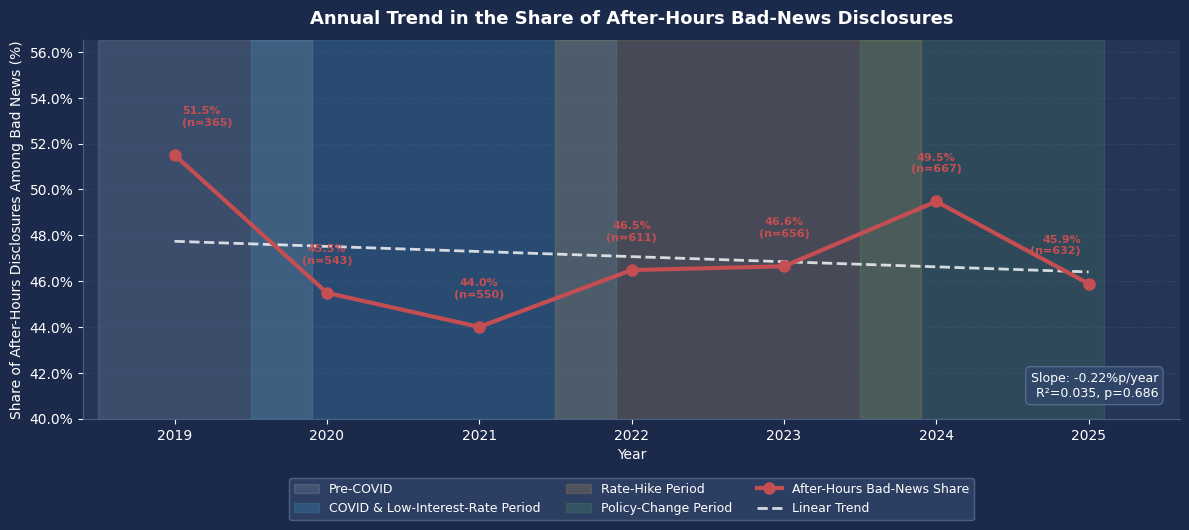

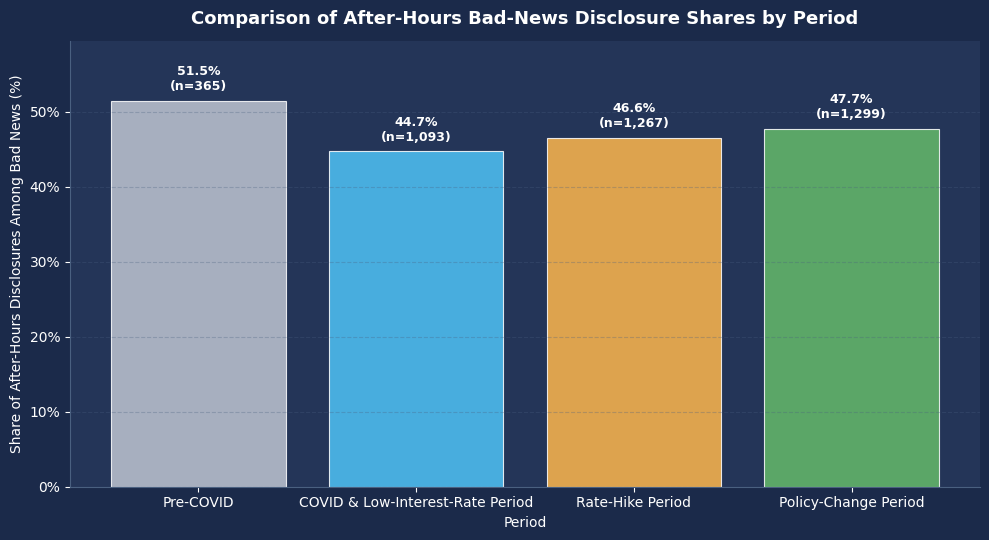


Files saved:
C:\Users\c2066\OneDrive\바탕 화면\corporate_disclosure_timing\analysis\outputs\05_yearly_bad_after_trend.png
C:\Users\c2066\OneDrive\바탕 화면\corporate_disclosure_timing\analysis\outputs\05_period_bad_after_comparison.png
C:\Users\c2066\OneDrive\바탕 화면\corporate_disclosure_timing\analysis\outputs\05_yearly_bad_after_trend.csv
C:\Users\c2066\OneDrive\바탕 화면\corporate_disclosure_timing\analysis\outputs\05_period_bad_after_comparison.csv


In [4]:
# ============================================================
# 5. Analysis of Changes in Patterns Over Time: Annual Trends
# - Annual share of after-hours bad-news disclosures, 2019–2025
# - Four periods: Pre-COVID / COVID & Low-Interest-Rate Period /
#   Rate-Hike Period / Policy-Change Period
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats
import statsmodels.formula.api as smf

BG_COLOR = "#1B2A4A"


# ------------------------------------------------------------
# 1. Construct Analysis Dataset
# ------------------------------------------------------------

trend_df = df_hb.copy()

trend_df = trend_df[
    trend_df["year"].between(2019, 2025)
    & trend_df["timing"].isin(
        ["Pre-market", "Intraday", "After-hours"]
    )
    & trend_df["news"].isin(
        ["Good News", "Bad News"]
    )
].copy()


trend_df["after_dummy"] = (
    trend_df["timing"] == "After-hours"
).astype(int)

trend_df["bad_dummy"] = (
    trend_df["news"] == "Bad News"
).astype(int)


# Indicator for after-hours bad-news disclosure
trend_df["bad_after"] = (
    (trend_df["bad_dummy"] == 1)
    & (trend_df["after_dummy"] == 1)
).astype(int)


# ------------------------------------------------------------
# 2. Create Period Classification Variable
# ------------------------------------------------------------

def assign_period(year):

    if year == 2019:
        return "Pre-COVID"

    elif year in [2020, 2021]:
        return "COVID & Low-Interest-Rate Period"

    elif year in [2022, 2023]:
        return "Rate-Hike Period"

    elif year in [2024, 2025]:
        return "Policy-Change Period"

    else:
        return "Other"


trend_df["period"] = (
    trend_df["year"]
    .apply(assign_period)
)


period_order = [
    "Pre-COVID",
    "COVID & Low-Interest-Rate Period",
    "Rate-Hike Period",
    "Policy-Change Period",
]


# ------------------------------------------------------------
# 3. Calculate Annual Share of After-Hours Bad-News Disclosures
# ------------------------------------------------------------

yearly_bad = (
    trend_df[
        trend_df["bad_dummy"] == 1
    ]
    .groupby("year")
    .agg(
        bad_total=("bad_dummy", "size"),
        bad_after=("after_dummy", "sum"),
    )
    .reset_index()
)


yearly_bad["bad_after_pct"] = (
    yearly_bad["bad_after"]
    / yearly_bad["bad_total"]
    * 100
)


# Total sample size by year
yearly_total = (
    trend_df
    .groupby("year")
    .agg(
        total=("news", "size"),
        bad_n=("bad_dummy", "sum"),
        good_n=(
            "bad_dummy",
            lambda x: (x == 0).sum()
        ),
    )
    .reset_index()
)


yearly_bad = yearly_bad.merge(
    yearly_total,
    on="year",
    how="left"
)


yearly_bad["period"] = (
    yearly_bad["year"]
    .apply(assign_period)
)


print(
    "\n=== Annual Share of "
    "After-Hours Bad-News Disclosures ==="
)

print(
    yearly_bad[
        [
            "year",
            "period",
            "total",
            "bad_total",
            "bad_after",
            "bad_after_pct"
        ]
    ]
    .round({
        "bad_after_pct": 1
    })
    .to_string(index=False)
)


# ------------------------------------------------------------
# 4. Calculate Share of After-Hours Bad-News Disclosures
#    by Period
# ------------------------------------------------------------

period_bad = (
    trend_df[
        trend_df["bad_dummy"] == 1
    ]
    .groupby("period")
    .agg(
        bad_total=("bad_dummy", "size"),
        bad_after=("after_dummy", "sum"),
    )
    .reindex(period_order)
    .reset_index()
)


period_bad["bad_after_pct"] = (
    period_bad["bad_after"]
    / period_bad["bad_total"]
    * 100
)


period_total = (
    trend_df
    .groupby("period")
    .agg(
        total=("news", "size"),
        bad_n=("bad_dummy", "sum"),
        good_n=(
            "bad_dummy",
            lambda x: (x == 0).sum()
        ),
    )
    .reindex(period_order)
    .reset_index()
)


period_bad = period_bad.merge(
    period_total,
    on="period",
    how="left"
)


print(
    "\n=== Share of After-Hours "
    "Bad-News Disclosures by Period ==="
)

print(
    period_bad[
        [
            "period",
            "total",
            "bad_total",
            "bad_after",
            "bad_after_pct"
        ]
    ]
    .round({
        "bad_after_pct": 1
    })
    .to_string(index=False)
)


# ------------------------------------------------------------
# 5. Annual Trend Test: Linear Trend
# ------------------------------------------------------------

slope, intercept, r_value, p_value, std_err = (
    stats.linregress(
        yearly_bad["year"],
        yearly_bad["bad_after_pct"]
    )
)


print(
    "\n=== Annual Linear Trend Test ==="
)

print(
    f"Slope: {slope:.3f}%p / year"
)

print(
    f"R²: {r_value ** 2:.4f}"
)

print(
    f"p-value: {p_value:.4f}"
)


# ------------------------------------------------------------
# 6. Disclosure-Level Logistic Regression:
#    Changes in the Probability of After-Hours Bad-News
#    Disclosure Across Periods
# ------------------------------------------------------------

bad_only = trend_df[
    trend_df["bad_dummy"] == 1
].copy()


bad_only["period"] = pd.Categorical(
    bad_only["period"],
    categories=period_order,
    ordered=True
)


logit_period = smf.logit(
    "after_dummy ~ C(period)",
    data=bad_only
).fit(
    disp=False
)


print(
    "\n=== Logistic Regression: "
    "Differences in After-Hours Disclosure Choice "
    "for Bad News Across Periods ==="
)

print(
    logit_period.summary()
)


# ------------------------------------------------------------
# 7. Visualization 1:
#    Annual Trend in the Share of After-Hours
#    Bad-News Disclosures
# ------------------------------------------------------------

years = yearly_bad[
    "year"
].values

bad_pct = yearly_bad[
    "bad_after_pct"
].values


fig, ax = plt.subplots(
    figsize=(12, 6)
)

fig.patch.set_facecolor(
    BG_COLOR
)

ax.set_facecolor(
    "#243558"
)


# Background shading for each period
periods = [
    (
        2019,
        2019.9,
        "#BFC5D2",
        "Pre-COVID"
    ),
    (
        2020,
        2021.9,
        "#4FC3F7",
        "COVID & Low-Interest-Rate Period"
    ),
    (
        2022,
        2023.9,
        "#FFB74D",
        "Rate-Hike Period"
    ),
    (
        2024,
        2025.1,
        "#66BB6A",
        "Policy-Change Period"
    ),
]


for x0, x1, color, label in periods:

    ax.axvspan(
        x0 - 0.5,
        x1,
        alpha=0.16,
        color=color,
        label=label,
        zorder=1
    )


# Actual annual shares
ax.plot(
    years,
    bad_pct,
    "o-",
    color=C_BAD,
    linewidth=3,
    markersize=8,
    label="After-Hours Bad-News Share",
    zorder=4
)


# Linear trend line
trend_line = (
    intercept
    + slope * years
)


ax.plot(
    years,
    trend_line,
    "--",
    color="#FFFFFF",
    linewidth=2,
    alpha=0.8,
    label="Linear Trend",
    zorder=3
)


# Data labels
for i, row in yearly_bad.iterrows():

    x = row["year"]
    y = row["bad_after_pct"]
    n = int(row["bad_total"])

    if i == 0:

        ha = "left"
        x_offset = 0.05

    elif i == len(yearly_bad) - 1:

        ha = "right"
        x_offset = -0.05

    else:

        ha = "center"
        x_offset = 0


    ax.annotate(
        f"{y:.1f}%\n(n={n:,})",
        xy=(x, y),
        xytext=(
            x + x_offset,
            y + 1.2
        ),
        textcoords="data",
        ha=ha,
        va="bottom",
        fontsize=8,
        color=C_BAD,
        fontweight="bold",
        zorder=5
    )


# Trend information box
trend_text = (
    f"Slope: {slope:.2f}%p/year\n"
    f"R²={r_value ** 2:.3f}, "
    f"p={p_value:.3f}"
)


ax.text(
    0.98,
    0.05,
    trend_text,
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
    color="white",
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="#32476B",
        edgecolor="#5D7092",
        alpha=0.85
    )
)


# Axis settings
y_min = (
    bad_pct.min() - 4
)

y_max = (
    bad_pct.max() + 5
)


ax.set_ylim(
    y_min,
    y_max
)

ax.set_xlim(
    years[0] - 0.6,
    years[-1] + 0.6
)


ax.set_xticks(
    years
)

ax.set_xlabel(
    "Year",
    fontsize=10
)

ax.set_ylabel(
    "Share of After-Hours Disclosures "
    "Among Bad News (%)",
    fontsize=10
)


ax.set_title(
    "Annual Trend in the Share of "
    "After-Hours Bad-News Disclosures",
    fontsize=13,
    fontweight="bold",
    pad=12
)


ax.yaxis.set_major_formatter(
    mtick.PercentFormatter()
)


# Remove duplicate legend entries and place legend below
handles, labels = (
    ax.get_legend_handles_labels()
)

unique = dict(
    zip(
        labels,
        handles
    )
)


legend = ax.legend(
    unique.values(),
    unique.keys(),
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        -0.14
    ),
    fontsize=9,
    ncol=3,
    framealpha=0.75
)


legend.get_frame().set_facecolor(
    "#32476B"
)

legend.get_frame().set_edgecolor(
    "#5D7092"
)


ax.spines[
    ["top", "right"]
].set_visible(False)

ax.spines[
    ["left", "bottom"]
].set_color("#4A6080")


ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3,
    color="#4A6080",
    zorder=1
)


plt.tight_layout(
    rect=[
        0,
        0.08,
        1,
        1
    ]
)


plt.savefig(
    OUTPUT_DIR
    / "05_yearly_bad_after_trend.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR
)


plt.show()


# ------------------------------------------------------------
# 8. Visualization 2:
#    Share of After-Hours Bad-News Disclosures by Period
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 5.5)
)

fig.patch.set_facecolor(
    BG_COLOR
)

ax.set_facecolor(
    "#243558"
)


period_colors = [
    "#BFC5D2",
    "#4FC3F7",
    "#FFB74D",
    "#66BB6A"
]


bars = ax.bar(
    period_bad["period"],
    period_bad["bad_after_pct"],
    color=period_colors,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.8
)


for bar, pct, n in zip(
    bars,
    period_bad["bad_after_pct"],
    period_bad["bad_total"]
):

    ax.text(
        bar.get_x()
        + bar.get_width() / 2,
        pct + 1.0,
        f"{pct:.1f}%\n"
        f"(n={int(n):,})",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="white"
    )


ax.set_ylim(
    0,
    period_bad[
        "bad_after_pct"
    ].max() + 8
)


ax.set_xlabel(
    "Period",
    fontsize=10
)

ax.set_ylabel(
    "Share of After-Hours Disclosures "
    "Among Bad News (%)",
    fontsize=10
)


ax.set_title(
    "Comparison of After-Hours "
    "Bad-News Disclosure Shares by Period",
    fontsize=13,
    fontweight="bold",
    pad=12
)


ax.yaxis.set_major_formatter(
    mtick.PercentFormatter()
)


ax.spines[
    ["top", "right"]
].set_visible(False)

ax.spines[
    ["left", "bottom"]
].set_color("#4A6080")


ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3,
    color="#4A6080",
    zorder=1
)


plt.tight_layout()


plt.savefig(
    OUTPUT_DIR
    / "05_period_bad_after_comparison.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR
)


plt.show()


# ------------------------------------------------------------
# 9. Save Results
# ------------------------------------------------------------

yearly_bad.to_csv(
    OUTPUT_DIR
    / "05_yearly_bad_after_trend.csv",
    index=False,
    encoding="utf-8-sig"
)


period_bad.to_csv(
    OUTPUT_DIR
    / "05_period_bad_after_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)


print(
    "\nFiles saved:"
)

print(
    OUTPUT_DIR
    / "05_yearly_bad_after_trend.png"
)

print(
    OUTPUT_DIR
    / "05_period_bad_after_comparison.png"
)

print(
    OUTPUT_DIR
    / "05_yearly_bad_after_trend.csv"
)

print(
    OUTPUT_DIR
    / "05_period_bad_after_comparison.csv"
)

# 5. Analysis of Changes in Patterns Over Time

## 5.1 Analysis Objective

This section examines how the proportion of after-hours bad-news disclosures changed over the 2019–2025 period.

In particular, the analysis divides the sample into the following four macroeconomic periods.

| Period | Classification |
|---|---|
| 2019 | Pre-COVID |
| 2020–2021 | COVID & Low-Interest-Rate Period |
| 2022–2023 | Rate-Hike Period |
| 2024–2025 | Policy-Change Period |

This classification is used to test whether firms' disclosure-timing strategies vary with changes in the macroeconomic environment.

---

## 5.2 Annual Trend in the Share of After-Hours Bad-News Disclosures

The annual analysis shows that the proportion of after-hours disclosures among bad-news announcements fluctuated between 44.0% and 51.5%.

In 2019, the share of after-hours bad-news disclosures was the highest at 51.5%. During the COVID and low-interest-rate period, it declined to 45.5% in 2020 and 44.0% in 2021.

The proportion subsequently increased to approximately 46% during the rate-hike period (2022–2023) and reached 49.5% in 2024.

However, the annual linear trend test indicates that there was no statistically significant long-term increasing or decreasing trend.

```text
Slope = -0.223%p/year
R² = 0.035
p = 0.686
```

Thus, although the proportion of after-hours bad-news disclosures varied from year to year, there is no evidence of a persistent structural increase or decrease over the sample period.

---

## 5.3 Comparison of After-Hours Bad-News Disclosure Shares by Period

The proportion of after-hours bad-news disclosures across the four periods was as follows.

| Period | After-Hours Bad-News Share |
|---|---:|
| Pre-COVID | 51.5% |
| COVID & Low-Interest-Rate Period | 44.7% |
| Rate-Hike Period | 46.6% |
| Policy-Change Period | 47.7% |

The share of after-hours bad-news disclosures was lowest during the COVID and low-interest-rate period and subsequently increased during the rate-hike and policy-change periods.

This may suggest that firms made relatively less use of disclosure-timing strategies during the period characterized by exceptionally low interest rates and abundant liquidity.

In contrast, the use of after-hours disclosures showed an increasing tendency after market uncertainty and interest-rate pressures intensified.

---

## 5.4 Logistic Regression Results

A logistic regression restricted to bad-news disclosures was conducted to examine changes in the probability of choosing after-hours disclosure across periods. The coefficient for the COVID and low-interest-rate period was negative and statistically significant.

```text
C(period)[T.COVID & Low-Interest-Rate Period] = -0.272
p = 0.025
```

This indicates that firms were significantly less likely to choose after-hours disclosure during the COVID and low-interest-rate period than during the pre-COVID period.

In contrast, the coefficients for the rate-hike and policy-change periods were negative but not statistically significant.

In addition, the likelihood ratio test for the overall model was not statistically significant (`p = 0.134`), and the model's explanatory power (Pseudo R²) was also very low.

Therefore, period-level differences alone do not appear to provide sufficient explanatory power for firms' choices of after-hours disclosure timing.

---

## 5.5 Overall Interpretation

Overall, the proportion of after-hours bad-news disclosures varied to some extent across different macroeconomic environments.

In particular, the share of after-hours bad-news disclosures declined during the COVID and low-interest-rate period and subsequently showed an increasing tendency as market uncertainty intensified.

However, the long-term trend analysis does not identify a statistically significant increasing or decreasing trend.

These findings suggest that firms' disclosure-timing strategies may be partially influenced by specific macroeconomic conditions, but there is insufficient evidence to conclude that such strategies have undergone a persistent structural change over time.